IA - Project (Popout)

## 4.2) Decision Trees:  
&nbsp;Em relação a Árvores de Decisão iremos usar o ID3 procedure para implementar um programa que aprende uma arvore de decisão dado um dataset, além disso o programa também deve estar preparado para aceitar exemplos de testes. O ID3 usa a noção de **Entropia** para quantificar se um atributo é "bom", "razoável", ou "ruim" em relação a classificação de um **Target**.  
&nbsp; Considerando uma variável aleatória $X$ que pode assumir valores $x_1 \dots x_n$, a probabilidade de acontecer cada valor é presentado por $P(x_n)$, e a quantidade $\log 2\frac{1}{P(x_i)}$ representa o quão o evento $x_i$ é inesperado, a média desses valores é o que chamamos de **Entropia** de $x$:
<div align="center">
  <img src="img/Screenshot 2026-04-24 172129.png" width="500px">
  <br>
  <sup><b>Figura 1:</b> Retirada do slide - IA 2526 Class 7 Learning.</sup>
</div>  

&nbsp;Para implementar, em código, o cálculo de entropia, utilizaremos Python (v. 3.14.3), com a ajuda da biblioteca NumPy - usada para cálculos numéricos científicos com alta precisão. A função a seguir, implementa a **Entropia**:



In [1]:
import numpy as np 
#1) Calculo de entropia (pagina 30 - slide 7)
def entropia(y): #recebe os exemplos da variável target
    nome_classes, contagem = np.unique(y,return_counts=True) #função 'unique' retorna o nome e a quantidade de classes em y
    prob = contagem/len(y) #probabilidade: quantidade de ocorrencia de uma classe/ tamanho do dataset
    return -np.sum(prob*np.log2(prob)) #Entropia: soma de -p * log2(p) (mensura a incerteza em cima de uma alguma variável X)

&nbsp;Dessa forma, a **Entropia** mensura o nível de incerteza da variável $X$. Para além disso, trabalhamos também com a noção de probabilidade condicional, isto é, considerando duas variáveis aleatórias $X$ e $Y$, $P(X|Y)$ representa a probabilidade de $X$ ocorrer dado que $Y$ ocorreu, essa noção matemática é combinada com a noção supracitada de **Entropia**, assim temos a **Entropia Condicional**:  

<div align="center">
  <img src="img/Screenshot 2026-04-24 181759.png" width="500px">
  <br>
  <sup><b>Figura 2:</b> Retirada do slide - IA 2526 Class 7 Learning.</sup>
</div>  

&nbsp;A **Entropia Condicional** carrega a informação da média de incerteza de uma variável aleatória $X$ quando $Y$ foi observada, definidas então **Entropia** (também chamada de **Entropia Total**) e a **Entropia Condicional**, conseguimos o **Ganho de informação**:  

<div align="center">
  <img src="img/Screenshot 2026-04-24 182401.png" width="500px">
  <br>
  <sup><b>Figura 3:</b> Retirada do slide - IA 2526 Class 7 Learning.</sup>
</div>  

&nbsp;O **Ganho de informação** representa a informação sobre $X$ contida em $Y$ e vice-versa. Em Python, implementamos essa noção a partir da seguinte função:

In [2]:
#2) Calculo de ganho de informaçao (pagina 31, 32 - slide 7)
def ganho_informacao(df,atributo,y): #recebe o dataset, as variáveis atributos X (x1, ... ,xn) e a variável target y
    entropia_total = entropia(y) #calcula a entropia H(c)
    classes,contagens = np.unique(df[atributo],return_counts=True) #retorna os nomes e quantidades de cada 'balde' dentro de uma feature em X
    entropia_condiconal = 0 #inicial em 0

    for classe in range(len(classes)): # Para cada classe de um atributo, H(C|Atributo) ou seja a prob de C sabendo de um atributo em especifico
        subset = df[df[atributo] == classes[classe]] #define um subset do dataset, apenas com o atributo analisado, daquela classe em especifico
        prob_subgrupo = contagens[classe]/len(df) #calcula a prob de uma classe em especifico aparecer no dataset daquele atributo
        entropia_condiconal += prob_subgrupo* entropia(subset[y]) #soma das prob de cada subgrupo * a entropia do total do subgrupo
    return entropia_total - entropia_condiconal #ganho de informaçao (slide 33 - Ganho(A) = I(C;A) = H(C)-H(C|A))

&nbsp;Com ambas funções **entropia** e **ganho_informacao** devidamente implementadas, podemos partir para a implementação do **Algoritmo ID3**. O **ID3** é um procedimento utilizado para criar **Árvores de Decisão** utilizando as noções anteriores, ir definindo, de maneira recursiva, o melhor atributo $X$ que está "mais fortemente ligado" a $Y$.  
&nbsp;O **ID3** precisa receber 3 informações: 
1. Dataset a ser analisado;
2. Lista das variáveis independentes $X$ a serem analisadas;
3. Variável target $y$.    

&nbsp;Começamos por criar a **raiz** da árvore, sendo tal uma função recursiva, temos 2 principais caso-bases (condições de parada): 
1. Se todos os exemplos analisados tem a mesma label para o target -> retorna a árvore (raiz), com essa label;
2. Se $X$ está vazia -> retorna a árvore (raiz), com a label sendo o valor de $y$ que mais aparece no dataset.    

&nbsp;Então, chamamos a função auxiliar  **Ganho de Informação** para decidir qual é o melhor atributo 'A' para esse dataset, e definimos a raiz com 'A',
e para cada valor possível de 'A', adicionamos um novo galho (branch) à árvore, e definimos um subset para 'A':
1. Se esse dataset estiver vazio -> adiciona um nó folha label sendo o valor de $y$ que mais aparece no subset;
2. Senão, criamos uma subárvore, e chamamos recursivamente a função, agora recebendo: o subset, $X-A$ e $y$.
No final, retornamos árvore.  
&nbsp;Nossa implementação foi completamente baseada no molde so slide fornecido no moodle da cadeira:  

<div align="center">
  <img src="img/Screenshot 2026-04-24 184423.png" width="500px">
  <br>
  <sup><b>Figura 4:</b> Retirada do slide - IA 2526 Class 7 Learning.</sup>
</div>  

&nbsp;Para o desenvolvimento desse código em Python, optamos pela implementação das árvores através de **dicionários** aninhados, a implementação do **ID3** é dada pela seguinte função:



In [3]:
#3) implementaçao do ID3 (implementado a partir do pseudocodigo da pagina 35 - slide 7)
def my_ID3(Examples,X,y):
    if len(np.unique(y)) == 1: #se todos os exemplos tem o mesmo valor de target retorna a root com esse valor - caso base
        return np.unique(y)[0]
    if X.empty: #se nao tem variavel independente retorna a moda de y - case base quando ja reparou todos as features
        return y.mode()[0]
    
    ganhos = [] #cria lista de ganhos
    for var_ind in X.columns: #calcula o ganho de informação de cada variavel independente 
        valor_ganho = ganho_informacao(Examples,var_ind,y.name) 
        ganhos.append(valor_ganho) #add ganho i na lista de ganhos

    indice_melhor = np.argmax(ganhos) #acha o indce da lista do maior ganho
    A = X.columns[indice_melhor] #define A como o maior dos ganhos
    #A é definido como o melhor classificador do dataset
    tree = {A: {}} #cria a root da arvore (com inmpletaçao de dicionario)
    #pega o melhor atributo A, e adiciona os baldes como chave externa
    #exemplo, se A = 'petallenhth', tree = {'petallenght" = {}}
    #tree['petallength']['Pequeno'] = 'Iris-setosa' #folha
    #tree['petallength']['Grande'] = {'sepalwidth': {}} #outro nó (sub-árvore)
    for valor in Examples[A].unique(): #itera sobre os valores possives dado a feature escolhida A
        subset = Examples[Examples[A] == valor] #faz com que o set de exemplos analisados seja Examples(vi)
        if subset.empty: #se esse subset for vazio
            tree[A][valor] = y.mode()[0] #escolhe a moda de y
        else: #cria nova  lista de var inde tirando antigo A
            novos_X = X.drop(A, axis=1) #remove o A que ja foi escolhido
            novo_y = subset[y.name]
            tree[A][valor] = my_ID3(subset,novos_X,novo_y) #chama recursivamente a funçao para os novos valores
    return tree

&nbsp;Para além da criação da **Árvore de Decisão** também é de interesse pode **classificar** novos exemplos, com base da árvore criada pelo **ID3**, para assim tentar 'prever' a variável target de novos exemplos com base na inteligencia adquirida pela árvore. Para executar tal, implementamos a seguinte função em Python:

In [4]:
#4) define classifcador para output do ID3
def classificador(exemplo,arvore): #recece novo exemplo e arvore gerada pelo ID3
    if not isinstance(arvore,dict): #se a arvore nao der um dict (dict aninhado), chegamos em uma folha
        return arvore
    
    atributo = list(arvore.keys())[0] #pega o atributo que está no no da arvore
    valor_exemplo = exemplo[atributo] #pega o valor q o exemplo tem paar esse atributo

    if valor_exemplo in arvore[atributo]: #segue pelo ramo correspondente
        sub_arvore = arvore[atributo][valor_exemplo]
        return classificador(exemplo, sub_arvore)
    else: #caso o valor nao existe - !!!(talvez posso duar aqui para retornar a moda)!!!
        return "Classe Desconhecida"

&nbsp;Agora que temos as funções **entropia, ganho_informacao, my_ID3 e classificado** obtemos todo o necessário para colocar em prática nosso algoritmo de **Árvore de Decisão**. Para iniciar, vamos testar no dataset fornecido no moodle, o 'iris dataset', esse dataset contém informações sobre uma especie de planta, essa planta é classificada em 3 categorias (variável target y): *Iris-virginica, Iris-versicolor e Iris-setosa*, a partir de 4 atributos (variáveis independentes X): *sepallength, sepalwidth, petallength e petalwidth*. Usaremos a biblioteca Pandas para leitura e manipulação de tal dataset:

In [5]:
import pandas as pd

df = pd.read_csv('../data/raw/iris.csv') #le o dataset
df.head(5) # mostra as 5 primeiras linhas

,ID,sepallength,sepalwidth,petallength,petalwidth,class
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


&nbsp;A primeira alteração necessária para aplicar o **ID3** é discretizar os valores dos atributos, aqui percebemos que as variáveis independentes apresentam valores numéricos contínuos, porém para que o **ID3** construa uma árvore de tamanho aplicável, vamos transformar esse valores em intervalos ('baldes') com a ajuda da função 'qcut' do Pandas:

In [6]:
df = pd.read_csv('../data/raw/iris.csv')

df_disc = df.drop('ID', axis=1) #remove a coluna desnecessária 'ID'

features = df_disc.drop('class',axis=1) #define as colunas que serão discretizadas
#função qcut pega uma coluna, divide na quantidade solicitada baseado nos quartis da amostra
for feature in features:
    df_disc[feature] = pd.qcut(df[feature], 3, labels=["Pequeno", "Médio", "Grande"])

df_disc.to_csv('../data/processed/iris_discretizado.csv', index=False) #guarda dataset discretizado em um novo arquivo
df_disc.head(5)


,sepallength,sepalwidth,petallength,petalwidth,class
0,Pequeno,Grande,Pequeno,Pequeno,Iris-setosa
1,Pequeno,Médio,Pequeno,Pequeno,Iris-setosa
2,Pequeno,Médio,Pequeno,Pequeno,Iris-setosa
3,Pequeno,Médio,Pequeno,Pequeno,Iris-setosa
4,Pequeno,Grande,Pequeno,Pequeno,Iris-setosa


&nbsp;Agora nosso dataset (iris_discretizado.csv) está pronto para o uso do **ID3**. Vamos definir $X$ e $y$ e então finalmente visualizar a **Árvore de Decisão** que o **ID3** aprendeu para o dataset em questão. Usamos o json (JavaScript Object Notation), para poder visualizar a árvore de maneira pouco mais estruturada:

In [7]:
X = df_disc.drop('class', axis=1) #Define as variáveis independentes: sepallength, sepalwidth, petallength e petalwidth
y = df_disc['class'] #Define variável target: class
data = df_disc #passa tudo como os exemplos

arvore = my_ID3(data,X,y) #recebe a árvore final
import json
print(json.dumps(arvore,indent=4, ensure_ascii=False))

{
    "petalwidth": {
        "Pequeno": "Iris-setosa",
        "Médio": {
            "petallength": {
                "Médio": "Iris-versicolor",
                "Grande": {
                    "sepallength": {
                        "Médio": {
                            "sepalwidth": {
                                "Pequeno": "Iris-virginica"
                            }
                        },
                        "Grande": "Iris-virginica"
                    }
                }
            }
        },
        "Grande": {
            "sepalwidth": {
                "Médio": {
                    "petallength": {
                        "Médio": {
                            "sepallength": {
                                "Médio": "Iris-virginica"
                            }
                        },
                        "Grande": {
                            "sepallength": {
                                "Grande": "Iris-virginica",
                           

&nbsp;Buscando uma melhor visualização gráfica, usamos a biblioteca matplotlib para criar uma função auxiliar que desenha a árvore, essa função pode ser visitada através do caminho relativo: 'plot/plot_DT.py'. O desenho da **Árvore de Decisão** aprendida pelo **algoritmo ID3** para o dataset **Iris Discretizado**, é o seguinte:

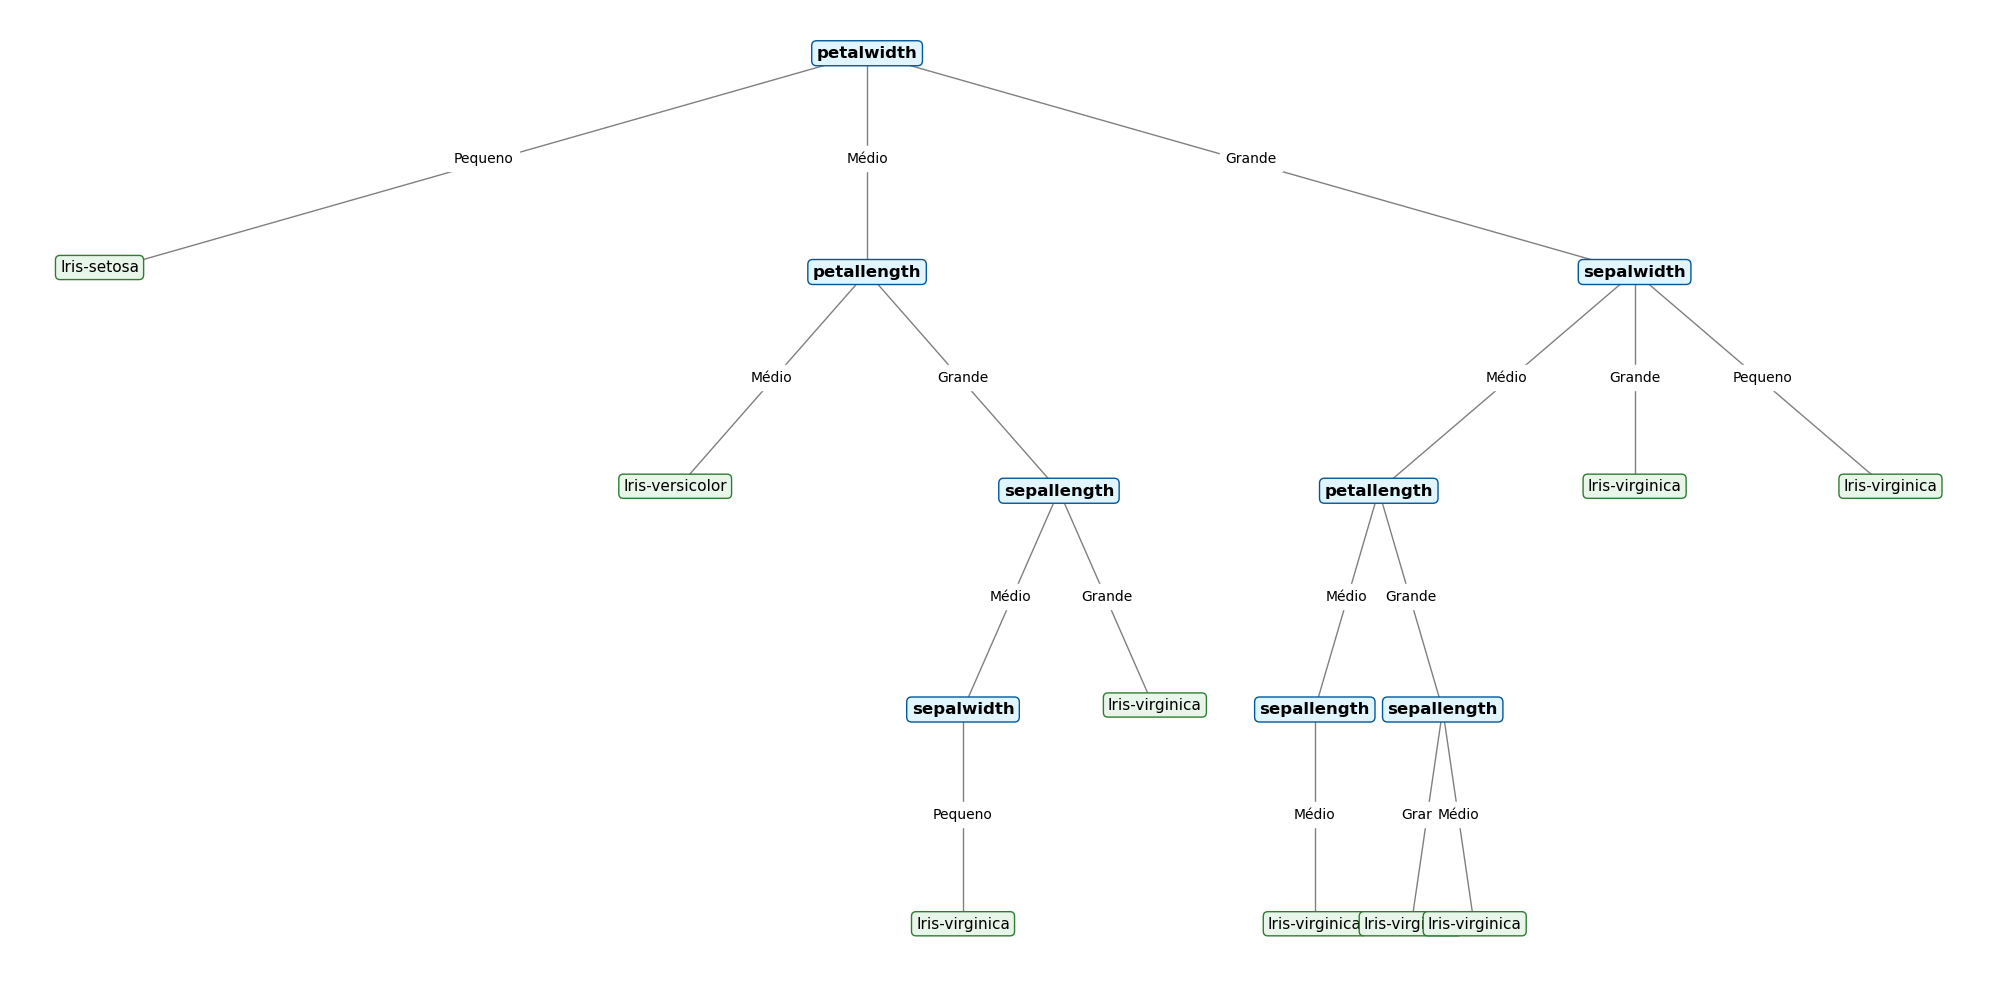

In [8]:
import plot.plot_DT as pp
%matplotlib inline
pp.desenhar(arvore)

&nbsp;A análise que temos a partir do desenho da árvore, é que a variável independente *petalwidth* foi escolhida como a melhor variável para classificar (A), tendo que se esse atributo, assumir a label 'Pequeno', já chegamos em uma folha, e podemos classificar o exemplo como *Iris-setosa*, seguimos por caminhos diferentes se *petalwidth*, assumir a label 'Média' podemos classificar como *Iris-Versicolor*, deixando assim todo o resto a classificar como *Iris-Virginica*, então um novo 'A' é calculado e atribuído para cada nova possibilidade. Sendo assim, percebemos que os dois atributos referentes a pétalas (*petalwidth* e *petalwidth*) são definitivamente mais decisores, e que a partir deles, a árvore começa a 'dar voltas' e olhar todos os outros, e mesmo assim, todos os novos caminhos darão em *Iris-virginica*, o que pode indicar 'outliers' nos dados ou 'overfitting' do modelo.  

&nbsp; Agora que conseguimos visualizar a **Árvore de Decisão** aprendida pelo **ID3**, vamos testar a sua performance em classificar novos exemplos, faremos alguns testes e estudaremos algumas métricas de performance:
1. Testar com os exatos mesmos dados de treino, sem a coluna target;
2. Usar o holdout validation para dividir 70% treino e 30% teste, para testar com exemplos que nunca foram vistos;


In [9]:
#1) Testar com os exatos mesmos dados de treino, sem a coluna target
df_teste = df_disc.drop('class', axis= 1) #teste é o dataset completo sem a coluna target
acertos = 0 #contador de acertos
lista_erros = [] #lista de erros
for i in range(len(df_teste)): #itera sobre todas as linhas do dataset
    exemplo = df_teste.iloc[i].to_dict() #cria um exemplo do index em formato dict
    real = df_disc.iloc[i]['class'] #busca a informação de target real no index i
    predicao = classificador(exemplo,arvore) #classifica o exemplo com a arvore acima 
    print(f'{i+1}) Real: {real} | Predição: {predicao}') #print o real vs oq foi predito
    if real == predicao: #se acertou
        acertos = acertos+1 #conta +1 em acertos
    else: #se errou
        lista_erros.append(i+1) #add o numero da linha do erro na lista de erros + 2 (pq começa em 0 e a primeira linha sao os titulos)
print(f'Acertos: {acertos} de {len(df_disc)}') #imprime acertos
print(f'Acurácia: {100*(acertos/len(df_disc))}%') #imprime acurácia
print(f'Errou nas linhas: {lista_erros}') #imprime lista de erros
    

1) Real: Iris-setosa | Predição: Iris-setosa
2) Real: Iris-setosa | Predição: Iris-setosa
3) Real: Iris-setosa | Predição: Iris-setosa
4) Real: Iris-setosa | Predição: Iris-setosa
5) Real: Iris-setosa | Predição: Iris-setosa
6) Real: Iris-setosa | Predição: Iris-setosa
7) Real: Iris-setosa | Predição: Iris-setosa
8) Real: Iris-setosa | Predição: Iris-setosa
9) Real: Iris-setosa | Predição: Iris-setosa
10) Real: Iris-setosa | Predição: Iris-setosa
11) Real: Iris-setosa | Predição: Iris-setosa
12) Real: Iris-setosa | Predição: Iris-setosa
13) Real: Iris-setosa | Predição: Iris-setosa
14) Real: Iris-setosa | Predição: Iris-setosa
15) Real: Iris-setosa | Predição: Iris-setosa
16) Real: Iris-setosa | Predição: Iris-setosa
17) Real: Iris-setosa | Predição: Iris-setosa
18) Real: Iris-setosa | Predição: Iris-setosa
19) Real: Iris-setosa | Predição: Iris-setosa
20) Real: Iris-setosa | Predição: Iris-setosa
21) Real: Iris-setosa | Predição: Iris-setosa
22) Real: Iris-setosa | Predição: Iris-seto

&nbsp;A partir desse teste, podemos visualizar que a árvore aprendeu de maneira muito satisfatória os exemplos de treino, dos 150 exemplos testados,conquistando uma acurácia de 98%, o classificador errou apenas 3 linhas, são essas:  

71) De X: {'sepallength': 'Médio', 'sepalwidth': 'Médio', 'petallength': 'Médio', 'petalwidth': 'Grande'}  

    De y: Real: Iris-versicolor | Predição: Iris-virginica    

<div align="center">
  <img src="img/dt_iris1.PNG" width="500px">
  <br>
  <sup><b>Figura 5:</b> Análise do Caminho Linha 71 - Árvore ID3 do 'Iris_discretizado'.</sup>
</div>  


78) De X: {'sepallength': 'Grande', 'sepalwidth': 'Médio', 'petallength': 'Grande', 'petalwidth': 'Grande'}  

    De y: Real: Iris-versicolor | Predição: Iris-virginica     

<div align="center">
  <img src="img/dt_iris2.PNG" width="500px">
  <br>
  <sup><b>Figura 6:</b> Análise do Caminho Linha 78 - Árvore ID3 do 'Iris_discretizado'.</sup>
</div>  

84) De X: {'sepallength': 'Médio', 'sepalwidth': 'Pequeno', 'petallength': 'Grande', 'petalwidth': 'Médio'}  

    De y: Real: Iris-versicolor | Predição: Iris-virginica   

<div align="center">
  <img src="img/dt_iris3.PNG" width="500px">
  <br>
  <sup><b>Figura 7:</b> Análise do Caminho Linha 84 - Árvore ID3 do 'Iris_discretizado'.</sup>
</div>  


&nbsp;Isso mostra que a escolha da label, é, nos 3 casos, sempre fiel ao desenho da **Árvore de Decisão**, porém podemos identificar que esses 3 casos não ficam definidos tributos referentes a pétalas (*petalwidth* e *petalwidth*), que são os atributos mais decisores, como apontados anteriormente, para entender o porque da classificação incorreta, vamos analisar o gráfico de dispersão dos dados do dataset, tanto para os atributos de pétalas, como para os atributos de sépalas (tais funções de plotagem podem ser acessadas em 'plot/plot_DT.py'):

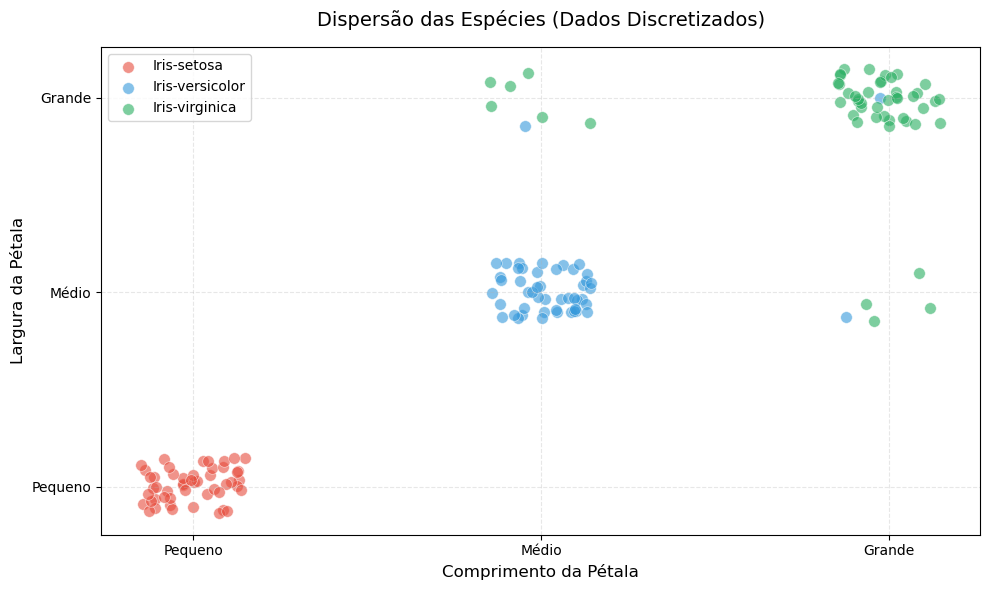

In [10]:
pp.plot_dispersao(df_disc) #Gráfico de Dispersão - Pétalas

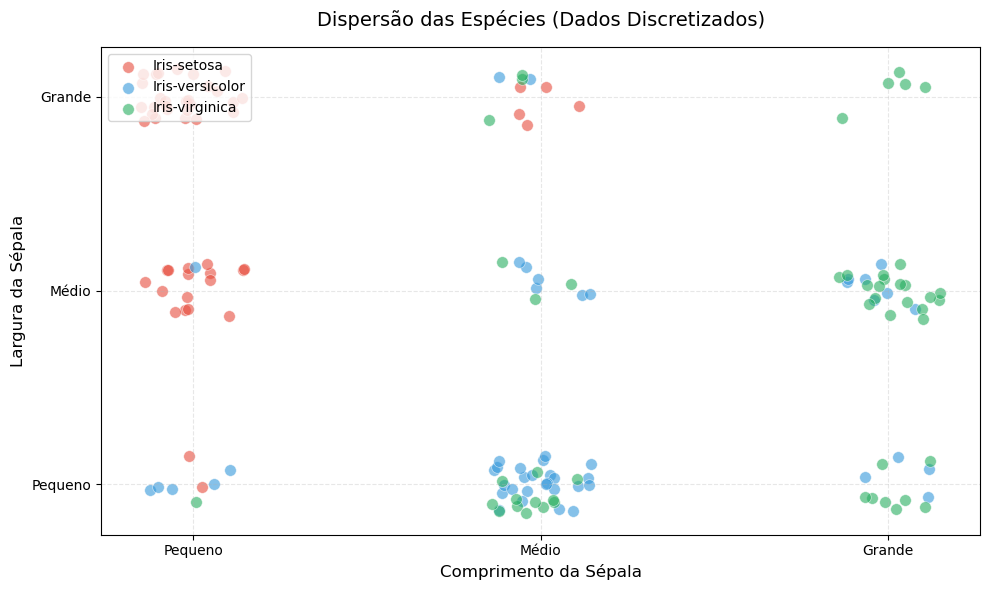

In [11]:
pp.plot_dispersao_sepal(df_disc) #Gráfico de Dispersão - Sépalas

&nbsp;Como já sugerido anteriormente, através desses dois gráficos, percebemos que os atributos de **pétalas**, conseguem separar muito bem para cada classe, exceto a 3 notórios outliers, diferente dos atributos de **sépalas** que não geram uma divisão linear tão clara. Usemos então o **Gráfico de Dispersão - Pétala** para análise mais minuciosa, ao estudar de perto os 3 outliers (pontos azuis - *Iris-Verticolor* ), que se misturam as zonas que mais naturalmente serias classificadas como verde *Iris-Virginica*, percebemos se tratar dos exatos 3 casos que foram previstos de maneira incorreta:
<div align="center">
  <img src="img/scatter_plot_iris_disc_petalas2.PNG" width="500px">
  <br>
  <sup><b>Figura 8:</b> Análise Gráfico de Dispersão - Pétalas do 'Iris_discretizado'.</sup>
</div>  

&nbsp;Com essa visualização cruzada ao desenho da árvore, conseguimos entender exatamente o motivo dos 3 casos terem labels erradas. Para ilustrar tal conclusão, olhemos para o **Gráfico de Decision Boundaries** (tal função de plotagem pode ser vista em 'plt/plot_DT.py'), esse gráfico divide o gráfico em regiões coloridas, onde cada cor representa uma categoria (classe), se um ponto cair na área rosa, o modelo o classifica como Classe A, se cair na verde, Classe B e as fronteiras são os limites onde o modelo muda de opinião sobre o que aquele dado representa:


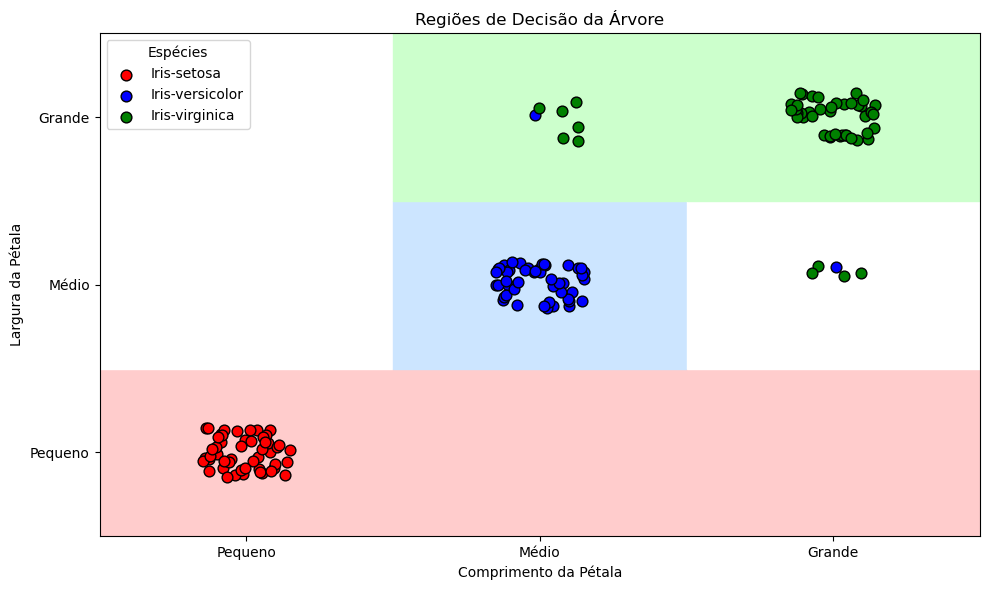

In [14]:
pp.plot_decision_boundaries(df_disc,arvore,classificador)

In [16]:
#2) Usar o holdout validation para dividir 70% treino e 30% teste, para testar com exemplos que nunca foram vistos;
df_shuffle = df_disc.sample(frac=1,random_state=42).reset_index(drop=True) #usa sample para randomizar os dados

df_shuffle.to_csv('../data/processed/iris_shuffle.csv', index=False) #guarda os dados embaralhados em novo arquivo
split_index = int(len(df_shuffle)*0.7) #acha quanto é o equivalente a 70% dentro desse dataset
df_treino = df_shuffle.iloc[:split_index] #define os primeros 70% do dataset para treino
df_test = df_shuffle.iloc[split_index:] #define os ultimos 30% do dataset para teste

print(f"Tamanho total de amostras do dataset: {len(df_shuffle)}")
print(f"Tamanho do dataset de treino (70%): {len(df_treino)}")
print(f"Tamanho do dataset de teste (30%): {len(df_test)}")

Tamanho total de amostras do dataset: 150
Tamanho do dataset de treino (70%): 105
Tamanho do dataset de teste (30%): 45


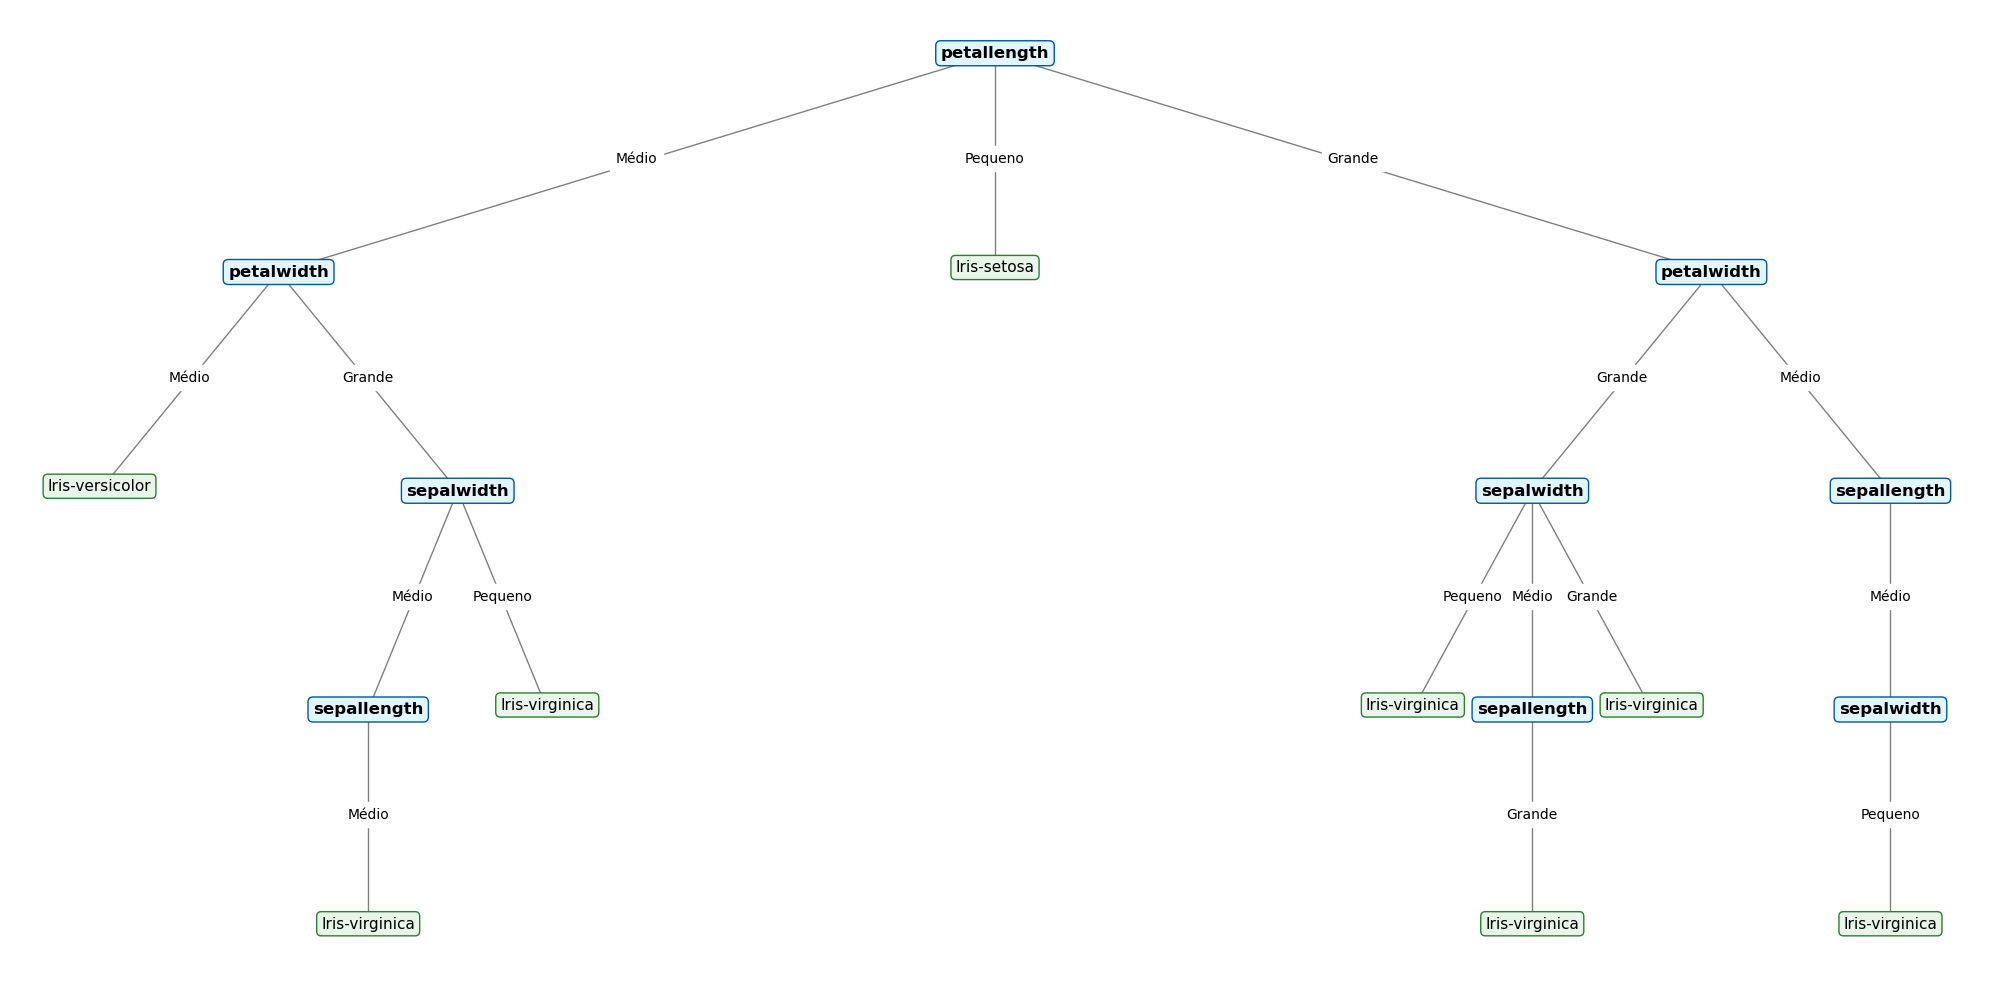

In [17]:
data = df_treino
X = df_treino.drop('class', axis=1)
y = df_treino['class']
arvore2 = my_ID3(df_treino, X,y)
pp.desenhar(arvore2)

In [21]:
df_test_X = df_test.drop('class', axis=1)
df_test_y = df_test['class']

acertos = 0
lista_erros = []
for i in range (len(df_test)):
    exemplo = df_test_X.iloc[i].to_dict()
    real = df_test_y.iloc[i]
    predicao = classificador(exemplo,arvore2)
    print(f"{i+1}) Real: {real} | Predição: {predicao}")
    if real == predicao:
        acertos = acertos +1
    else:
        lista_erros.append(i+1)
print(f"Acertou {acertos} de {len(df_test)}")
print(f"Acurácia: {acertos/len(df_test)}%")
print(f"Errou nos casos: {lista_erros}")



1) Real: Iris-setosa | Predição: Iris-setosa
2) Real: Iris-virginica | Predição: Iris-virginica
3) Real: Iris-virginica | Predição: Iris-virginica
4) Real: Iris-setosa | Predição: Iris-setosa
5) Real: Iris-versicolor | Predição: Iris-versicolor
6) Real: Iris-versicolor | Predição: Iris-versicolor
7) Real: Iris-virginica | Predição: Iris-virginica
8) Real: Iris-versicolor | Predição: Iris-versicolor
9) Real: Iris-virginica | Predição: Iris-virginica
10) Real: Iris-setosa | Predição: Iris-setosa
11) Real: Iris-virginica | Predição: Iris-virginica
12) Real: Iris-versicolor | Predição: Iris-versicolor
13) Real: Iris-virginica | Predição: Iris-virginica
14) Real: Iris-versicolor | Predição: Iris-versicolor
15) Real: Iris-versicolor | Predição: Iris-versicolor
16) Real: Iris-versicolor | Predição: Iris-versicolor
17) Real: Iris-setosa | Predição: Iris-setosa
18) Real: Iris-versicolor | Predição: Iris-versicolor
19) Real: Iris-versicolor | Predição: Iris-versicolor
20) Real: Iris-setosa | Pre

27) Real: Iris-virginica | Predição: Classe Desconhecida
{'sepallength': 'Grande', 'sepalwidth': 'Médio', 'petallength': 'Grande', 'petalwidth': 'Médio'}
39) Real: Iris-virginica | Predição: Classe Desconhecida
{'sepallength': 'Médio', 'sepalwidth': 'Médio', 'petallength': 'Grande', 'petalwidth': 'Grande'}